# Modelling exercise

This is the third part of the Data Science hiring assessment. The assessment further develops the business question from the first interview. 

The goal is to forecast demand for a given product(SKU)-Supermarket combination

### Load basic packages


In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

from utils import (
    read_demand,
    read_promotions,
    extend_promotions_days,
    merge,
    clean_demand_per_group,
    aggregate_to_weekly,
)

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

### Import Data


In [2]:
# Demand data
demand_df = read_demand('./demand.csv')
demand_df.head()

,demand,sku,supermarket
date,,,
2019-01-01,93.0,desperados,albert-heijn
2019-01-02,93.0,desperados,albert-heijn
2019-01-03,94.0,desperados,albert-heijn
2019-01-04,95.0,desperados,albert-heijn
2019-01-05,92.0,desperados,albert-heijn


In [3]:
# promotion data
promotions_df = read_promotions('./promotions.csv')
promotions_df.head()

,sku,supermarket
promotion_date,,
2020-09-26,desperados,jumbo
2019-09-18,desperados,jumbo
2021-09-28,desperados,jumbo
2021-02-11,desperados,jumbo
2021-10-03,desperados,dirk


# Prepare the data for modelling

Cleans the demand, merges with the promotion data, and aggregates to weekly data

In [4]:
def prepare_data(demand_df, promotions_df):
    extended_promotions_df = extend_promotions_days(promotions_df, 7).drop('promotion_id', axis=1)
    merge_df = merge(demand_df, extended_promotions_df)
    merge_df_clean = clean_demand_per_group(merge_df.copy())
    weekly = aggregate_to_weekly(merge_df_clean)
    weekly = weekly[weekly['n_days'] == 7].drop(columns='n_days').copy()
    return weekly

weekly_df = prepare_data(demand_df, promotions_df)
print('Shape of weekly_df:', weekly_df.shape)
weekly_df.head()

Shape of weekly_df: (1395, 4)


,sku,supermarket,demand,promotion
date,,,,
2019-01-13,desperados,albert-heijn,635.0,False
2019-01-20,desperados,albert-heijn,637.0,False
2019-01-27,desperados,albert-heijn,636.0,False
2019-02-03,desperados,albert-heijn,1013.0,False
2019-02-10,desperados,albert-heijn,644.0,False


## Demand forecasting approach

The business needs an 8-week-ahead weekly forecast for each (sku, supermarket). The EDA gives a clear picture of what we're working with.

**Why SARIMAX fits this problem**

- **Handles slow demand growth.** Demand is drifting up by 1-6% year-on-year on most pairs and the model picks that up on its own, no manual adjustment needed.
- **Learns from recent weeks where it helps.** If a week's demand tends to look like last week's, the model uses that signal. If it doesn't, it ignores it.
- **Captures the yearly pattern where it exists.** Summer rise on desperados, flat across the year for some others - the model fits each shape on its own, and won't force seasonality where there isn't any.
- **One model per (SKU, supermarket).** A high-volume pair and a low-volume one don't share settings — each gets its own forecast tuned to its own scale.

## Feature engineering and preprocessing

`weekly_df` from `prepare_data` above is already cleaned, merged, and aggregated to weekly. Partial-week boundary buckets are dropped (`n_days == 7` filter), so every row covers a full 7-day week.

On top of that, SARIMAX needs only its **exogenous regressors**:

- **Fourier(period=52, K=4)**
- **promotion** (0/1) - already on `weekly_df` from the merge.

We don't need lag features because SARIMAX learns its AR/MA structure internally from the `order=(p,d,q)` specification.

In [5]:
# Convert promotion to int
weekly_df['promotion'] = weekly_df['promotion'].astype(int)
print('weekly_df rows:', len(weekly_df), '  per series:', len(weekly_df) // 9)
print('date range:', weekly_df.index.min().date(), '->', weekly_df.index.max().date())

weekly_df rows: 1395   per series: 155
date range: 2019-01-13 -> 2021-12-26


## Time-series decomposition

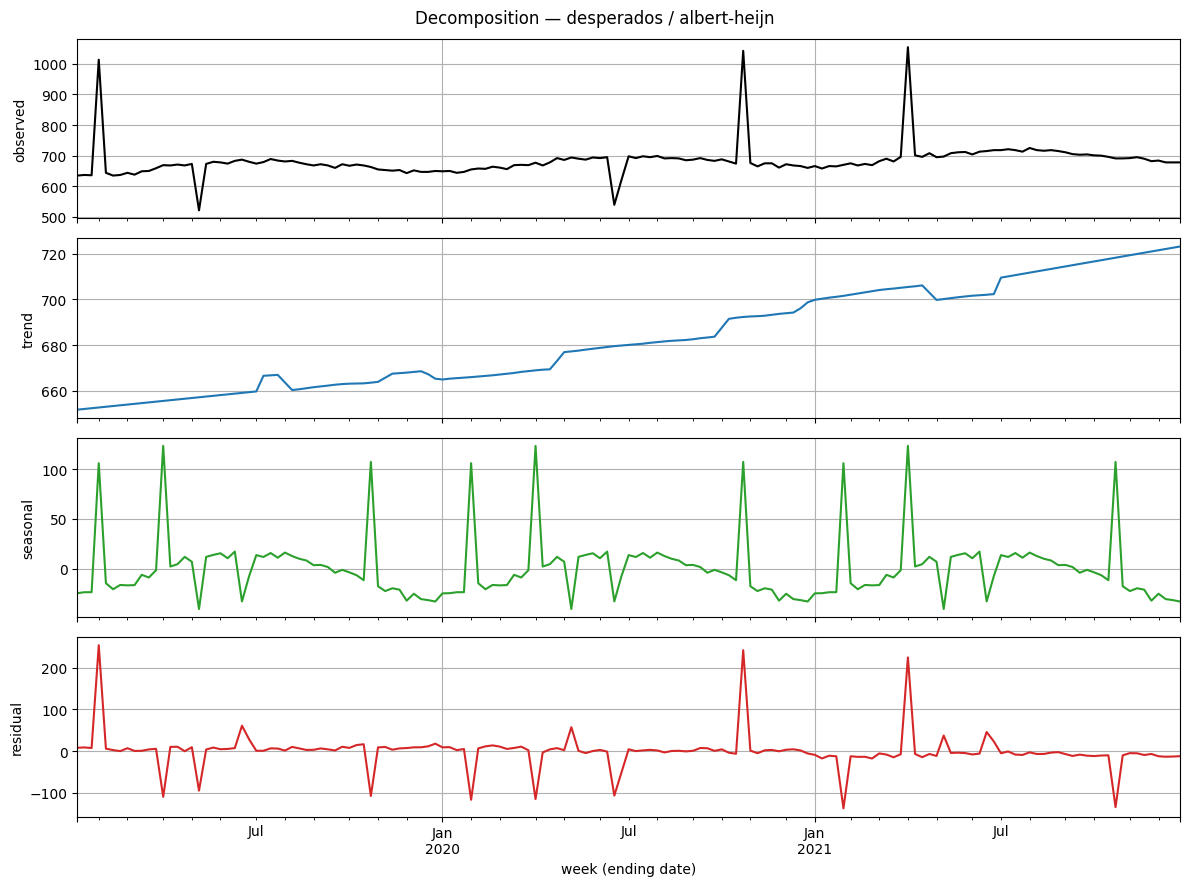

In [6]:
def plot_decomposition(sku, sm):
    s = (weekly_df[(weekly_df.sku == sku) & (weekly_df.supermarket == sm)]
            .demand.asfreq('W'))
    decomp = seasonal_decompose(s, model='additive', period=52, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    decomp.observed.plot(ax=axes[0], color='black'); axes[0].set_ylabel('observed')
    decomp.trend.plot(ax=axes[1], color='tab:blue'); axes[1].set_ylabel('trend')
    decomp.seasonal.plot(ax=axes[2], color='tab:green'); axes[2].set_ylabel('seasonal')
    decomp.resid.plot(ax=axes[3], color='tab:red'); axes[3].set_ylabel('residual')
    axes[3].set_xlabel('week (ending date)')
    fig.suptitle(f'Decomposition — {sku} / {sm}')
    plt.tight_layout()
    plt.show()


plot_decomposition('desperados', 'albert-heijn')

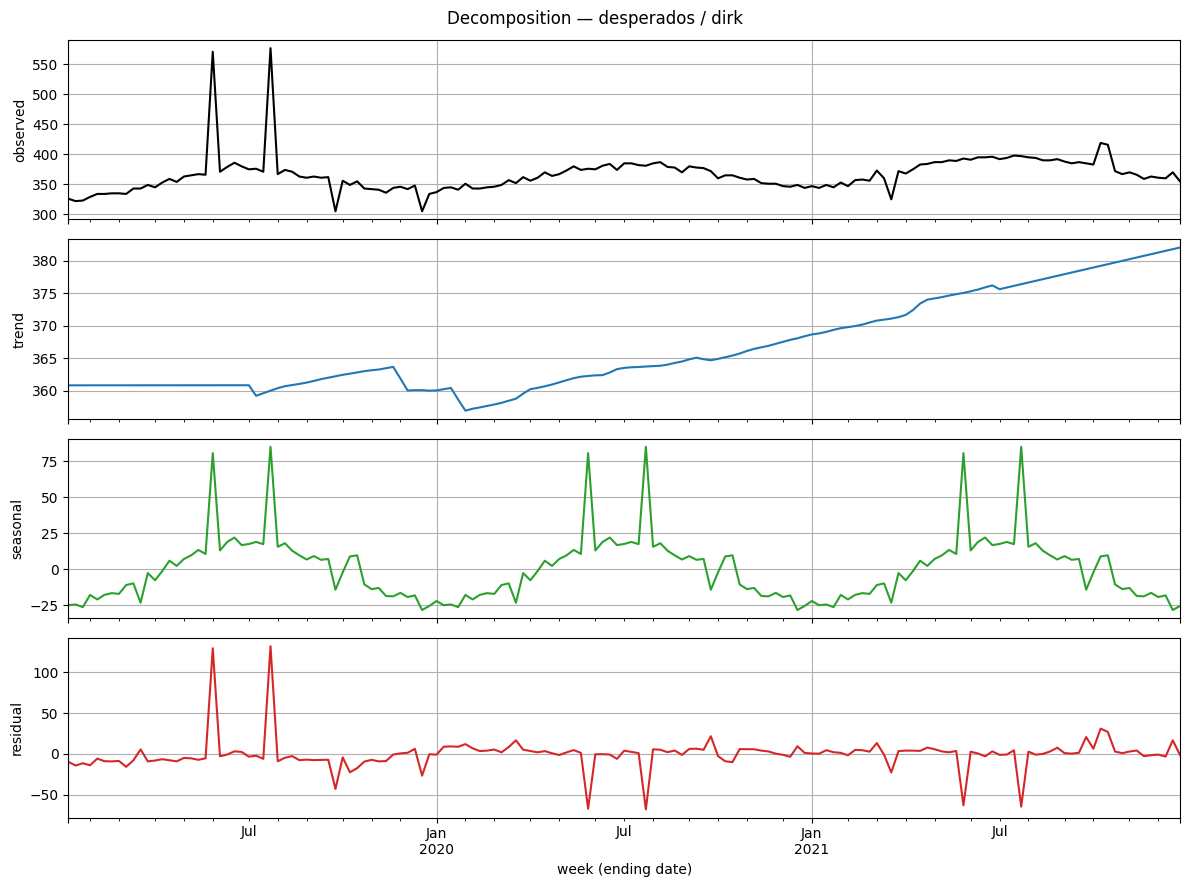

In [7]:
plot_decomposition('desperados', 'dirk')

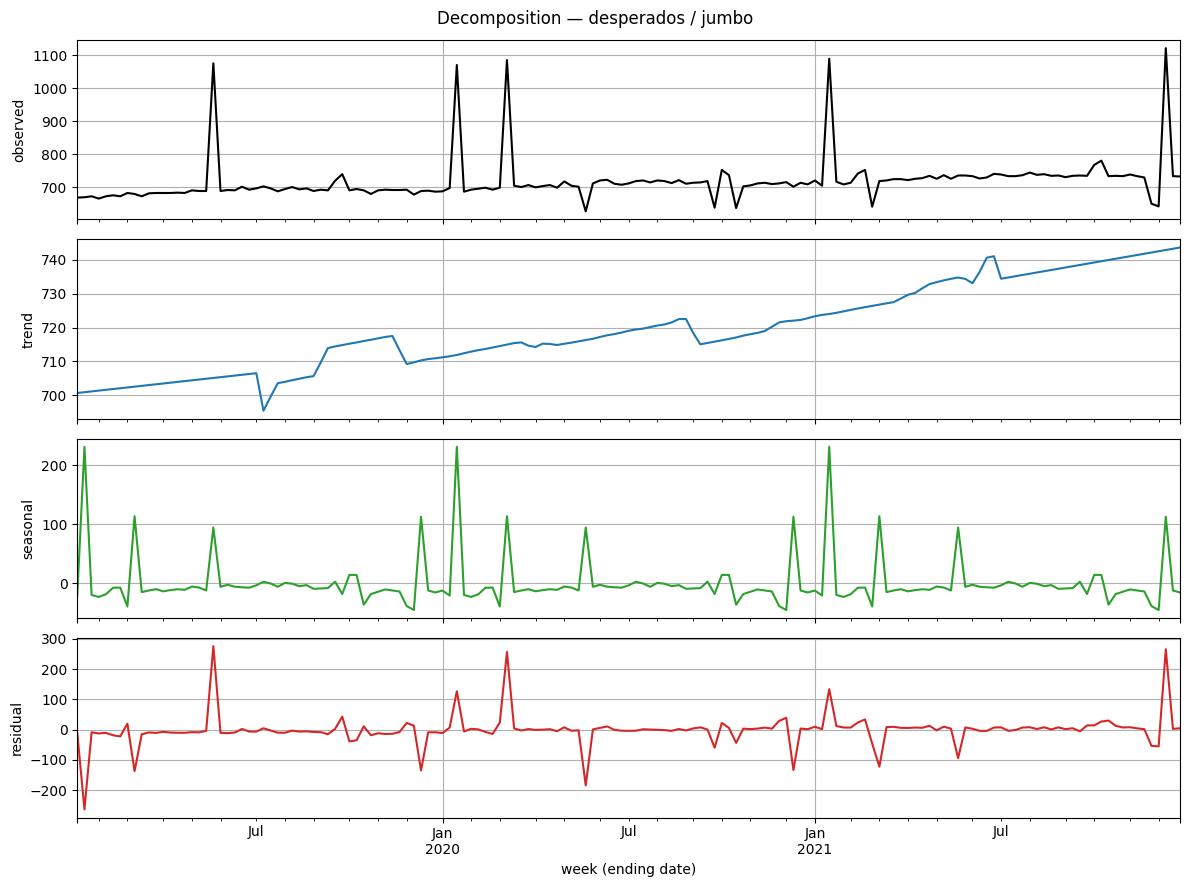

In [8]:
plot_decomposition('desperados', 'jumbo')

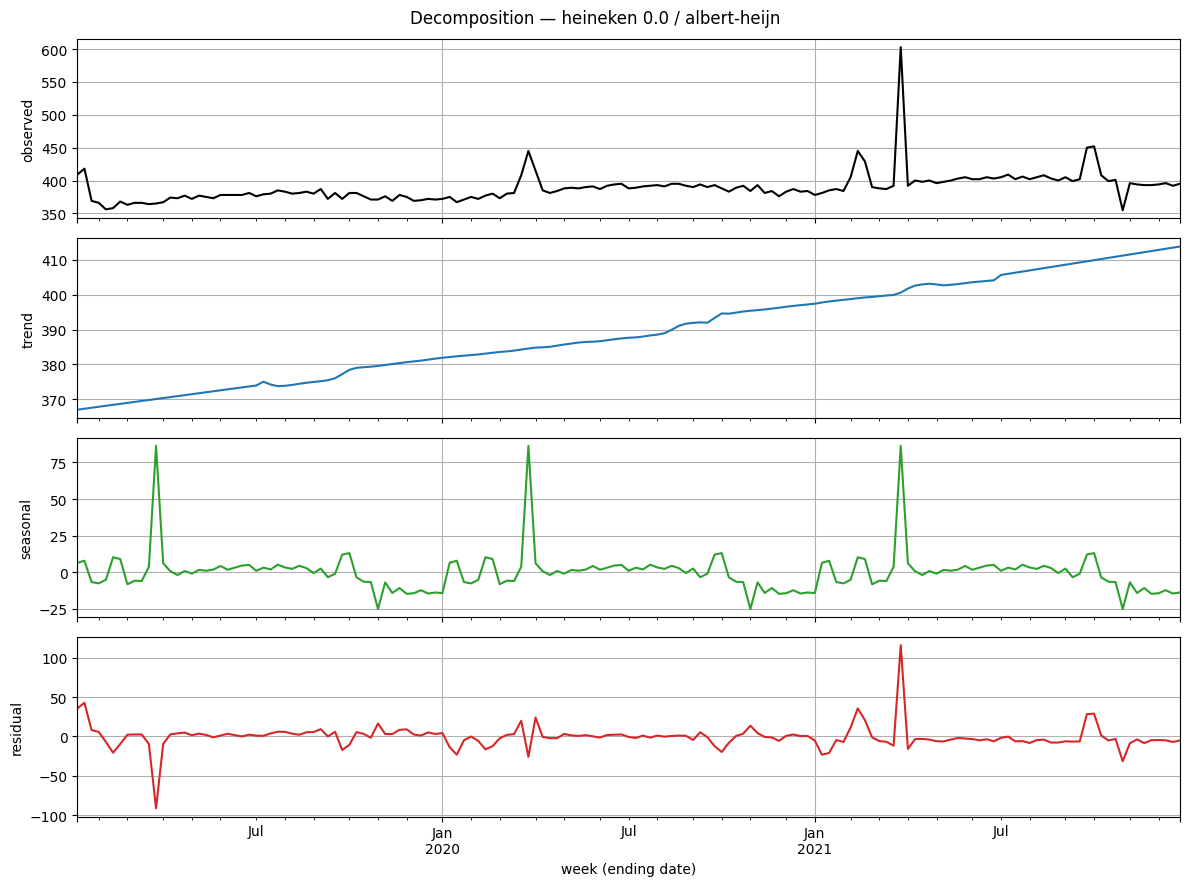

In [9]:
plot_decomposition('heineken 0.0', 'albert-heijn')

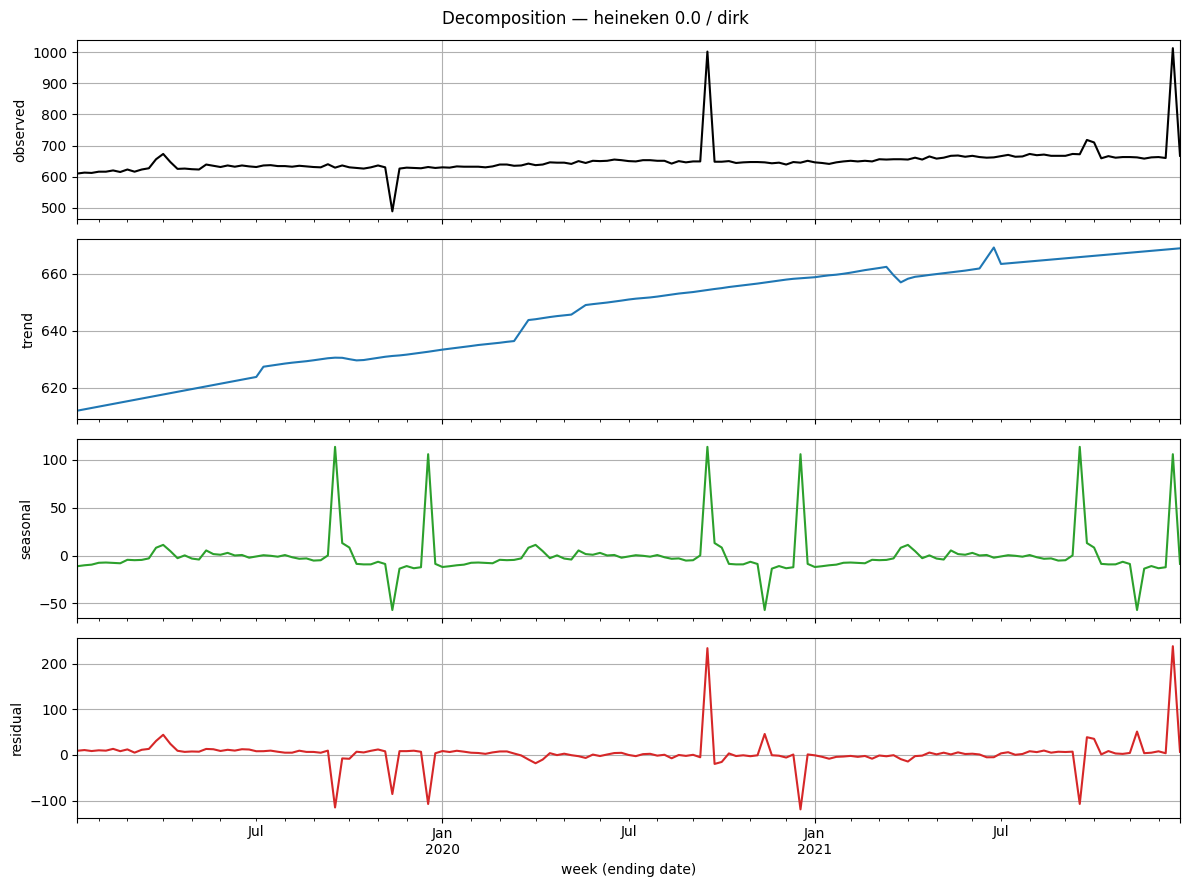

In [10]:
plot_decomposition('heineken 0.0', 'dirk')

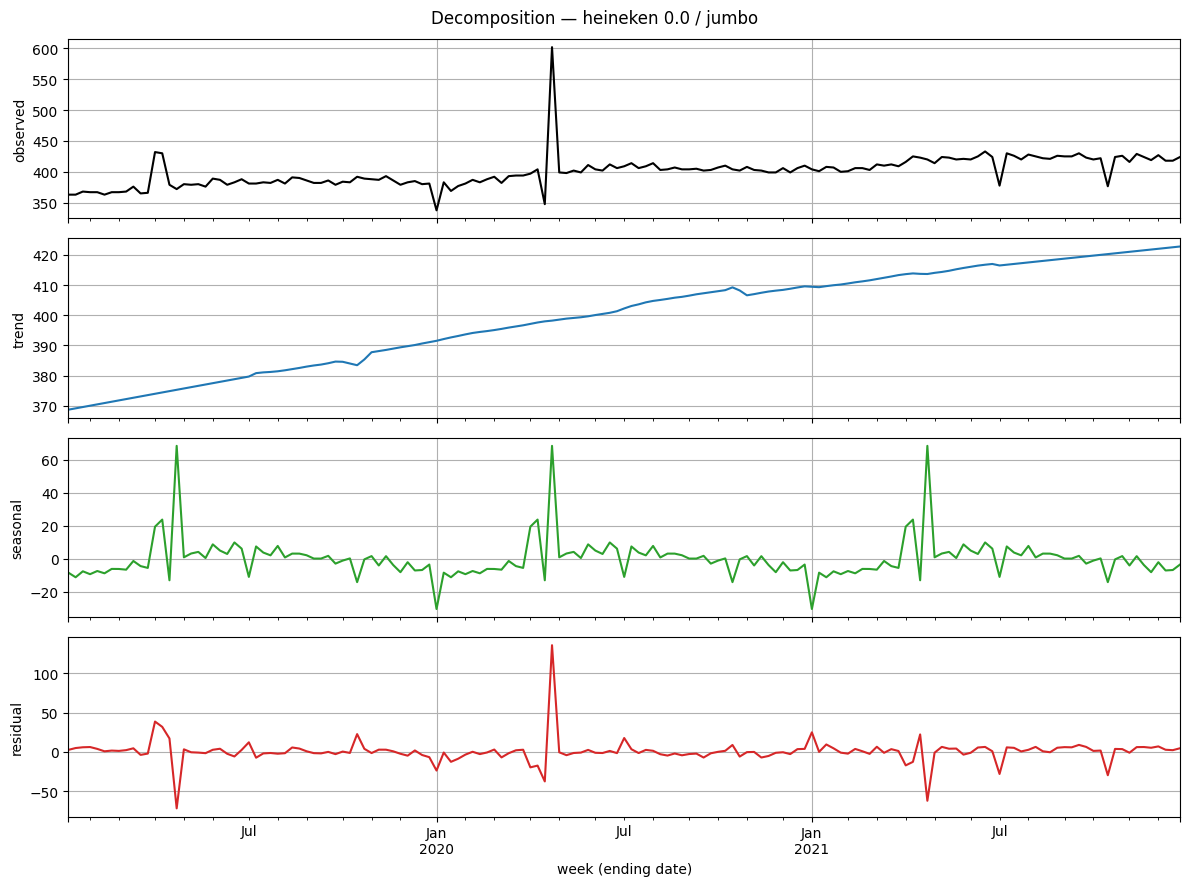

In [11]:
plot_decomposition('heineken 0.0', 'jumbo')

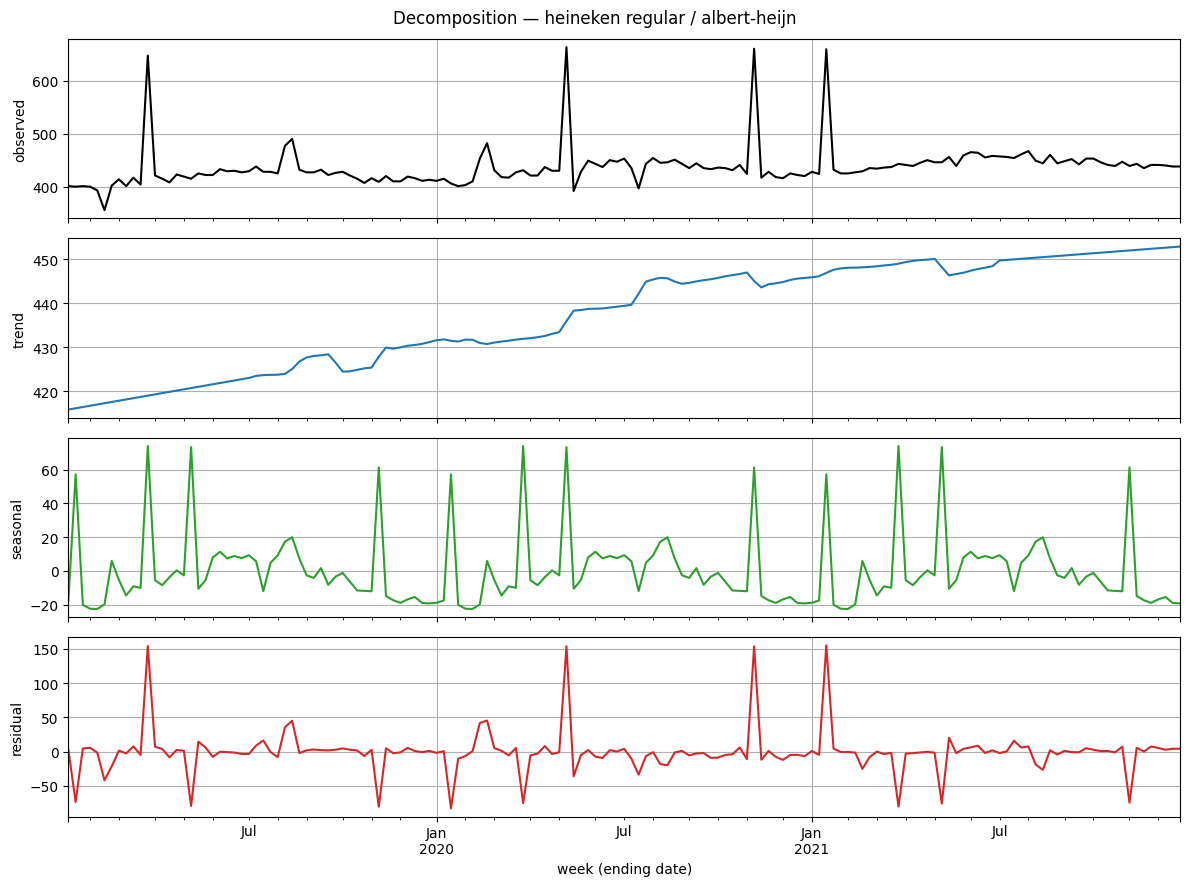

In [12]:
plot_decomposition('heineken regular', 'albert-heijn')

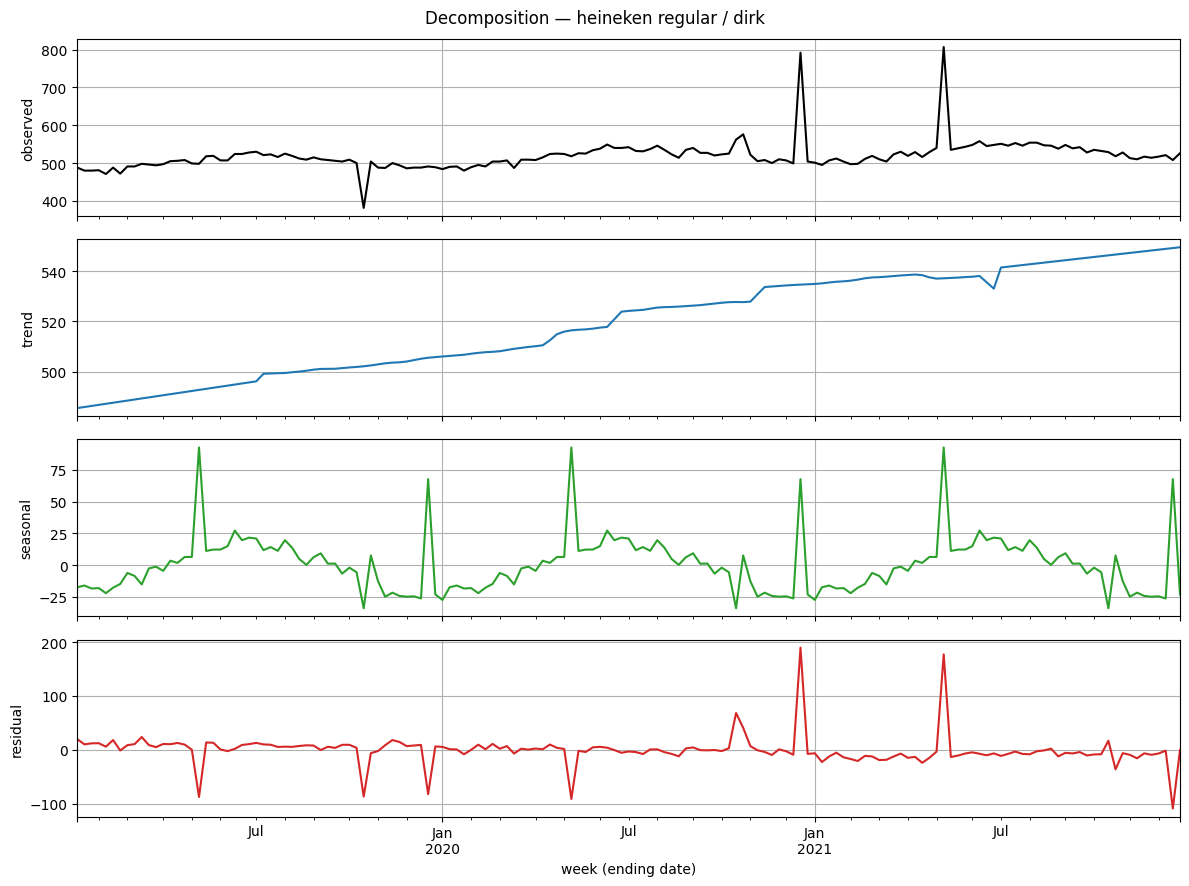

In [13]:
plot_decomposition('heineken regular', 'dirk')

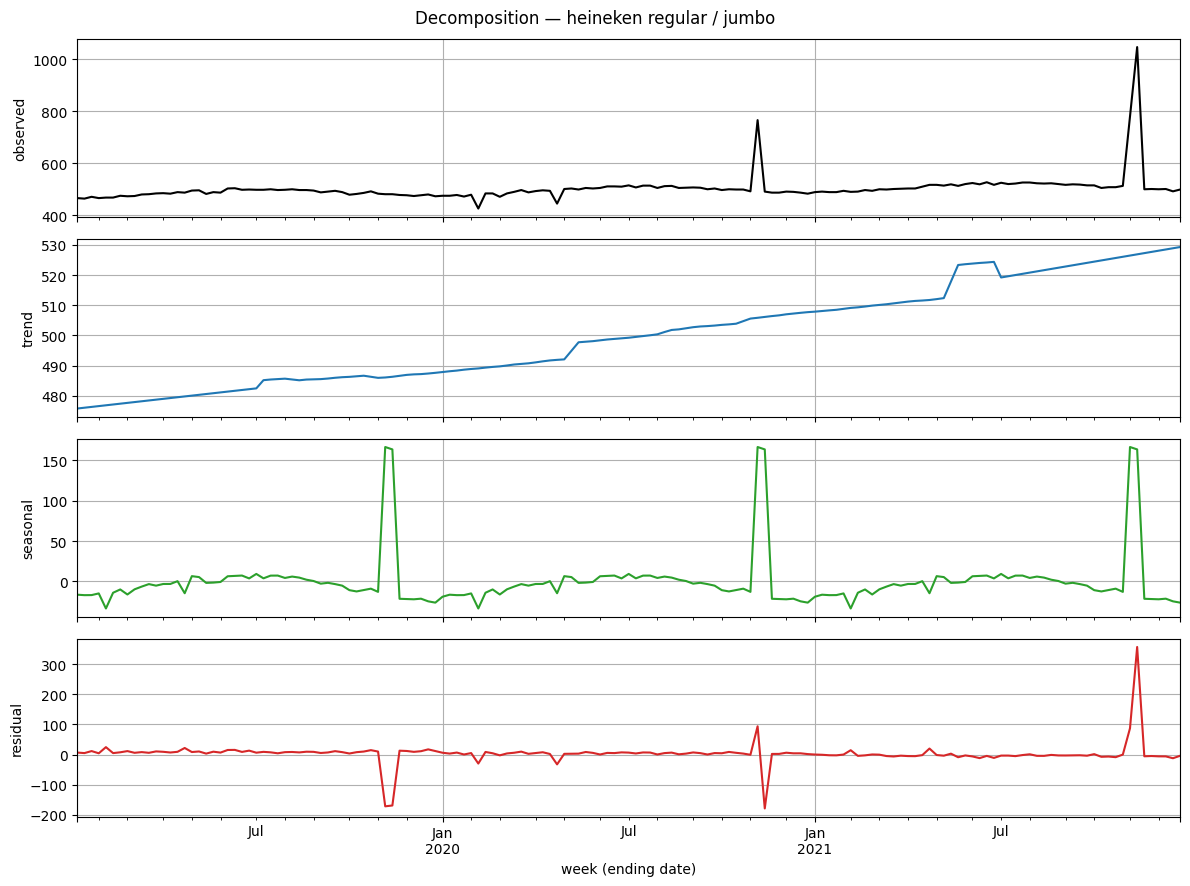

In [14]:
plot_decomposition('heineken regular', 'jumbo')

Looking across all 9 plots:

- **Trend** - most series drift up gently year over year, in line with the 1-6% year-on-year growth we measured in the EDA.
- **Seasonal** - the annual cycle is real but small everywhere.
- **Residual** - across the pairs with promo history, the residual is dominated by sharp positive spikes that land on promo weeks.

**What this confirms for the model**: SARIMAX(1, 1, 1) + Fourier(52, K=4) + promotion exog is the right structure.

## Train / test split

Train on everything through **2021-06-30**; test on the remainder of 2021 (~26 weeks per series).

In [15]:
CUTOFF = pd.Timestamp('2021-06-30')
n_train_per_series = (weekly_df.index <= CUTOFF).sum() // 9
n_test_per_series = (weekly_df.index > CUTOFF).sum() // 9
print('train weeks per series:', n_train_per_series, '  test weeks per series:', n_test_per_series)

train weeks per series: 129   test weeks per series: 26


## SARIMAX configuration

Per-series **SARIMAX(1, 1, 1)** with exogenous regressors.

- **p = 1** → How many past observations influence current value.
- **d = 1** → Used to make series stationary.
- **q = 1** → Dependency on past forecast errors.

These are the smallest non-zero values for each. Going higher (more lags, more differencing) is possible but with only ~155 weeks per series, simpler is safer.

**Other settings:**

- **Exogenous matrix** = Fourier annual seasonality (8 columns) + promotion flag (1 column) = 9 exog columns total.

In [16]:
# Fourier annual seasonality. K=4 -> 8 columns
def fourier_terms(t_start, length, period=52, K=4):
    t = np.arange(t_start, t_start + length)
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols)

In [17]:
# Fit SARIMAX per (sku, supermarket), forecast the hold-out window, collect predictions
fit_results = {}
test_preds = []

for (sku, sm), g in weekly_df.groupby(['sku', 'supermarket']):
    g = g.sort_index().asfreq('W')
    train = g.loc[g.index <= CUTOFF]
    test = g.loc[g.index > CUTOFF]
    n_train = len(train)

    exog_train = fourier_terms(0, n_train).set_index(train.index)
    exog_train['promotion'] = train['promotion'].astype(int).values
    exog_test = fourier_terms(n_train, len(test)).set_index(test.index)
    exog_test['promotion'] = test['promotion'].astype(int).values

    res = SARIMAX(
        train['demand'].astype(float),
        exog=exog_train,
        order=(1, 1, 1),
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=200)
    fit_results[(sku, sm)] = res

    fcst = res.forecast(steps=len(test), exog=exog_test)
    test_preds.append(pd.DataFrame({
        'date': test.index, 'sku': sku, 'supermarket': sm,
        'actual': test['demand'].values,
        'sarimax': np.maximum(fcst.values, 0.0).round(2),
    }))

In [18]:
test_pred_df = pd.concat(test_preds).set_index('date')
print('Test predictions:', len(test_pred_df), 'rows  (=', len(test_pred_df) // 9, 'per series x 9 series)')
test_pred_df.head()

Test predictions: 234 rows  (= 26 per series x 9 series)


,sku,supermarket,actual,sarimax
date,,,,
2021-07-04,desperados,albert-heijn,718.0,715.03
2021-07-11,desperados,albert-heijn,721.0,720.95
2021-07-18,desperados,albert-heijn,718.0,723.91
2021-07-25,desperados,albert-heijn,713.0,723.71
2021-08-01,desperados,albert-heijn,725.0,720.48


## Evaluation metrics

Two metrics, both reported overall and per (sku, supermarket):

- **MAE** - mean absolute error, on average we'd be off by N units this week.
- **MAPE %** - mean absolute percentage error, we're within ±X% of actual.

In [19]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    mae = float(np.mean(np.abs(y_true - y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100)
    return {'MAE': round(mae, 2), 'MAPE_%': round(mape, 2)}

# Overall.
overall = pd.DataFrame([metrics(test_pred_df['actual'], test_pred_df['sarimax'])], index=['sarimax'])
print('Overall hold-out metrics:')
print(overall)

# Per (sku, supermarket).
per_group = pd.DataFrame([
    {'sku': sku, 'supermarket': sm, **metrics(g['actual'], g['sarimax'])}
    for (sku, sm), g in test_pred_df.groupby(['sku', 'supermarket'])
]).set_index(['sku', 'supermarket'])
print('\nPer-series hold-out metrics:')
per_group

Overall hold-out metrics:
          MAE  MAPE_%
sarimax  18.8    2.92

Per-series hold-out metrics:


MAE  MAPE_%
sku              supermarket                
desperados       albert-heijn  11.71    1.67
                 dirk          15.41    3.98
                 jumbo         44.36    5.38
heineken 0.0     albert-heijn   4.58    1.17
                 dirk          30.47    3.85
                 jumbo         12.39    3.01
heineken regular albert-heijn   4.88    1.08
                 dirk           9.10    1.73
                 jumbo         36.32    4.41

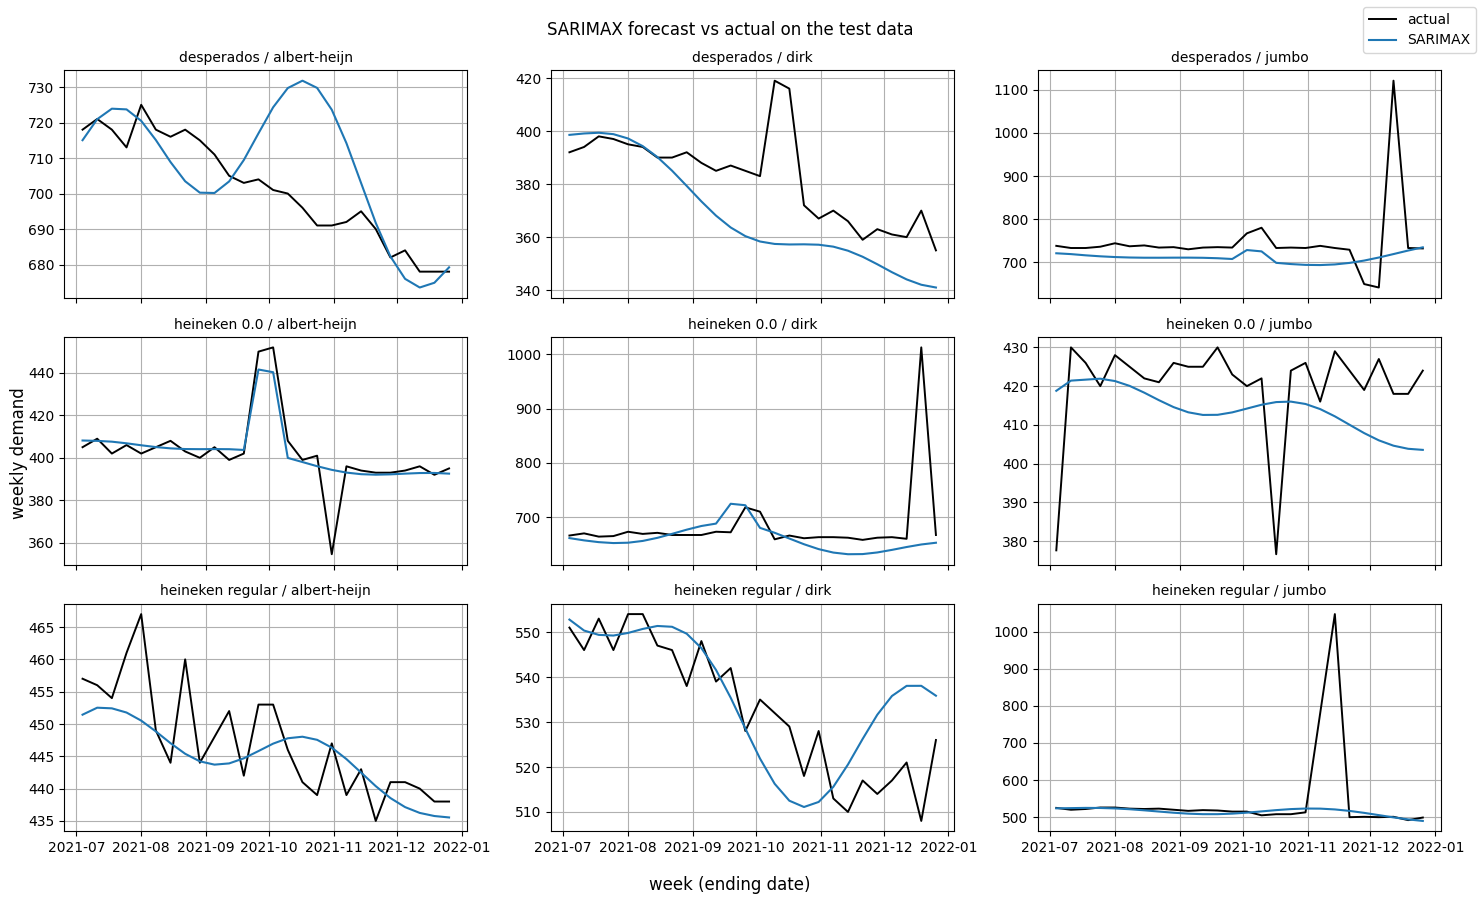

In [20]:
# Forecast vs actual on the test data, per series
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
for ax, ((sku, sm), g) in zip(axes.flat, test_pred_df.groupby(['sku', 'supermarket'])):
    ax.plot(g.index, g['actual'], color='black', lw=1.4, label='actual')
    ax.plot(g.index, g['sarimax'], color='tab:blue', label='SARIMAX')
    ax.set_title(f'{sku} / {sm}', fontsize=10)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
fig.suptitle('SARIMAX forecast vs actual on the test data')
fig.supxlabel('week (ending date)')
fig.supylabel('weekly demand')
plt.tight_layout()
plt.show()

## Out-of-sample 8-week-ahead forecast

Refit SARIMAX per series on all available data (through the last full week, 2021-12-26) and forecast 8 weeks ahead. The deliverable for the business is the predicted demand for the **week ending 2022-02-20** - the 8th step beyond the last observed week - together with an 80% prediction interval.

The data file contains historic promotions only; no future promo schedule was supplied. The forecast below sets `promotion = 0` for all 8 future weeks, so it is a non-promo baseline.

In [21]:
HORIZON = 8
future_idx = pd.date_range(
    weekly_df.index.max() + pd.Timedelta(days=7), periods=HORIZON, freq='W'
)
target_week = future_idx[-1]
print(f'Last observed week: {weekly_df.index.max().date()}')
print(f'Forecast horizon:   {future_idx[0].date()} -> {target_week.date()} (target = week {HORIZON})')

Last observed week: 2021-12-26
Forecast horizon:   2022-01-02 -> 2022-02-20 (target = week 8)


In [22]:
forecasts = []
for (sku, sm), g in weekly_df.groupby(['sku', 'supermarket']):
    g = g.sort_index().asfreq('W')
    n_train = len(g)

    exog_train = fourier_terms(0, n_train).set_index(g.index)
    exog_train['promotion'] = g['promotion'].astype(int).values
    exog_fut = fourier_terms(n_train, HORIZON).set_index(future_idx)
    exog_fut['promotion'] = 0

    res = SARIMAX(
        g['demand'].astype(float), 
        exog=exog_train,
        order=(1, 1, 1),
        enforce_stationarity=False, 
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=200)

    f = res.get_forecast(steps=HORIZON, exog=exog_fut)
    mean = f.predicted_mean
    ci = f.conf_int(alpha=0.20)  # 80% interval
    forecasts.append({
        'sku': sku, 'supermarket': sm,
        'target_week': target_week.date(),
        'predicted_demand': float(max(mean.iloc[-1], 0.0)),
        'lower_80': float(max(ci.iloc[-1, 0], 0.0)),
        'upper_80': float(max(ci.iloc[-1, 1], 0.0)),
    })

forecast_df = pd.DataFrame(forecasts).sort_values(['sku', 'supermarket'])
forecast_df[['predicted_demand', 'lower_80', 'upper_80']] = (
    forecast_df[['predicted_demand', 'lower_80', 'upper_80']].round(0).astype(int)
)
forecast_df

,sku,supermarket,target_week,predicted_demand,lower_80,upper_80
0,desperados,albert-heijn,2022-02-20,691,620,761
1,desperados,dirk,2022-02-20,361,329,393
2,desperados,jumbo,2022-02-20,749,657,840
3,heineken 0.0,albert-heijn,2022-02-20,396,372,420
4,heineken 0.0,dirk,2022-02-20,687,633,742
5,heineken 0.0,jumbo,2022-02-20,414,388,439
6,heineken regular,albert-heijn,2022-02-20,432,382,482
7,heineken regular,dirk,2022-02-20,509,465,553
8,heineken regular,jumbo,2022-02-20,517,450,583


## Forecast result summary

The 8-week-ahead forecast for the week ending **2022-02-20** is generated for every (SKU, supermarket) pair, with an 80% prediction interval around each predicted value.

**How accurate is the model?** Measured on the test data:

| Metric | Value | What it means in plain English |
|---|---|---|
| **MAE** | 18.8 units per week | The forecast is off by about 19 units in either direction on a typical week. |
| **MAPE** | 2.92% | The forecast is within ±2.9% of the actual demand on a typical week. |

**Bottom line:** the model is accurate enough to drive inventory orders directly. An average miss of around 3% gives the planner a tight enough buffer to work with, and the 80% prediction intervals give a sensible upper/lower band rather than a single point estimate.

**Note to remember:** the forecast assumes no promotions are running in the prediction window.